# Lab assignment №1, part 3

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the third part of the assignment. First and second parts are waiting for you in the same directory.*__

##  Part 3. SVM and kernels

Kernels concept get adopted in variety of ML algorithms (e.g. Kernel PCA, Gaussian Processes, kNN, ...).

So in this task you are to examine kernels for SVM algorithm applied to rather simple artificial datasets.

To make it clear: we will work with the classification problem through the whole notebook. 

In [23]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

Let's generate our dataset and take a look on it.

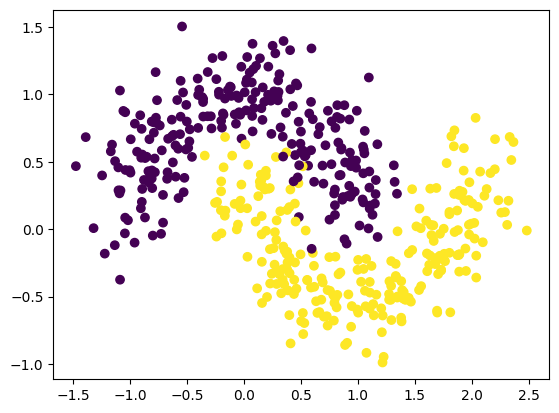

In [24]:
moons_points, moons_labels = make_moons(n_samples=500, noise=0.2, random_state=42)
plt.scatter(moons_points[:, 0], moons_points[:, 1], c=moons_labels)

## 1.1 Pure models.
First let's try to solve this case with good old Logistic Regression and simple (linear kernel) SVM classifier.

Train LR and SVM classifiers (choose params by hand, no CV or intensive grid search neeeded) and plot their decision regions. Calculate one preffered classification metric.

Describe results in one-two sentences.

_Tip:_ to plot classifiers decisions you colud use either sklearn examples ([this](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_alpha.html#sphx-glr-auto-examples-neural-networks-plot-mlp-alpha-py) or any other) and mess with matplotlib yourself or great [mlxtend](https://github.com/rasbt/mlxtend) package (see their examples for details)

_Pro Tip:_ wirte function `plot_decisions` taking a dataset and an estimator and plotting the results cause you want to use it several times below

/home/dima/Документы/ml/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


accuracy = 0.851, f1 = 0.851
accuracy_lr = 0.846, f1_lr = 0.846


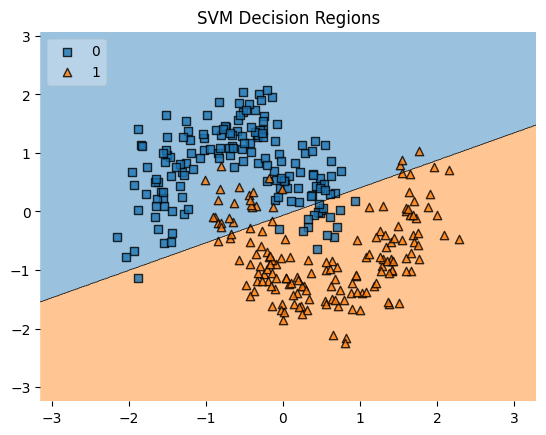

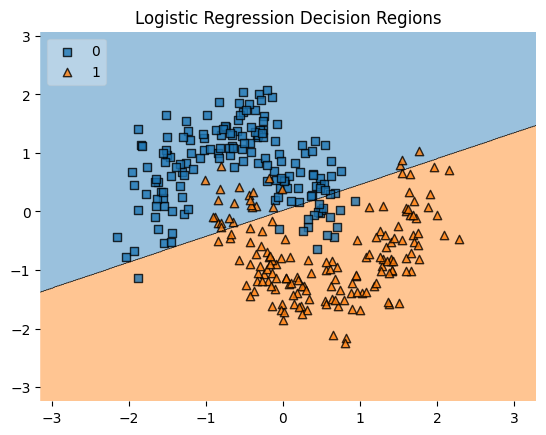

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

lr = LogisticRegression(solver='saga', tol=1e-3, max_iter=500, random_state=42) 
svm = SVC(kernel='linear', max_iter=500, random_state=42) 

X_train, X_test, y_train, y_test = train_test_split(moons_points, moons_labels, test_size=0.35)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"accuracy = {accuracy:.3f}, f1 = {f1:.3f}")

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print(f"accuracy_lr = {accuracy_lr:.3f}, f1_lr = {f1_lr:.3f}")


def plot_decisions(X, y, clf, title):
    plot_decision_regions(X, y, clf=clf, legend=2)
    plt.title(title)
    plt.show()

plot_decisions(X_train_scaled, y_train, svm, 'SVM Decision Regions')
plot_decisions(X_train_scaled, y_train, lr,  'Logistic Regression Decision Regions')

## 1.2 Kernel tirck

Now use different kernels (`poly`, `rbf`, `sigmoid`) on SVC to get better results. Play `degree` parameter and others.

For each kernel estimate optimal params, plot decision regions, calculate metric you've chosen eariler.

Write couple of sentences on:

* What have happenned with classification quality?
* How did decision border changed for each kernel?
* What `degree` have you chosen and why?

{'C': 1000, 'degree': 3, 'gamma': 0.1, 'kernel': 'poly'}
{'C': 10000, 'gamma': 0.1, 'kernel': 'rbf'}
{'C': 1, 'gamma': 0.01, 'kernel': 'sigmoid'}
accuracy_poly    = 0.8571
accuracy_rbf     = 0.9771
accuracy_sigmoid = 0.8400


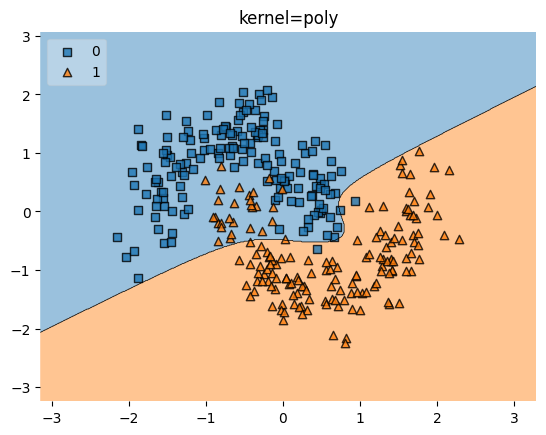

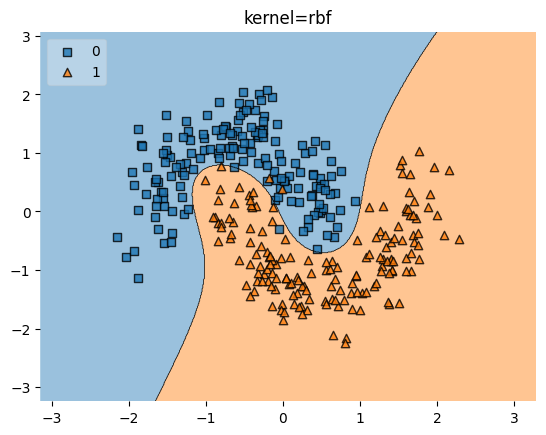

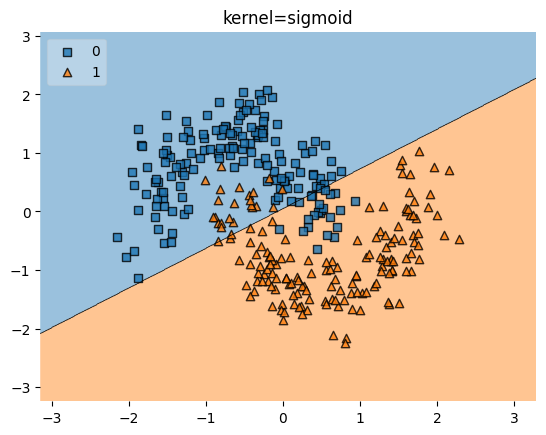

In [26]:
from sklearn.model_selection import GridSearchCV

svm_poly    = SVC(kernel='poly',    tol=1e-3, random_state=42)
svm_rbf     = SVC(kernel='rbf',     tol=1e-3, random_state=42)
svm_sigmoid = SVC(kernel='sigmoid', tol=1e-3, random_state=42)

param_grid_1 = {'C': [0.01, 0.1, 1, 10, 100, 1000, 10000], 'gamma': [0.1, 0.01], 'kernel': ['poly'], 'degree': [1, 2, 3, 4, 5, 10]}
param_grid_2 = {'C': [0.01, 0.1, 1, 10, 100, 1000, 10000], 'gamma': [0.1, 0.01], 'kernel': ['rbf']}
param_grid_3 = {'C': [0.01, 0.1, 1, 10, 100, 1000, 10000], 'gamma': [0.1, 0.01], 'kernel': ['sigmoid']}

grid1 = GridSearchCV(svm_poly   , param_grid_1, scoring='accuracy', cv=5)
grid2 = GridSearchCV(svm_rbf    , param_grid_2, scoring='accuracy', cv=5)
grid3 = GridSearchCV(svm_sigmoid, param_grid_3, scoring='accuracy', cv=5)
 
grid1.fit(X_train_scaled, y_train)
grid2.fit(X_train_scaled, y_train)
grid3.fit(X_train_scaled, y_train)

print(grid1.best_params_)
print(grid2.best_params_)
print(grid3.best_params_)

y_pred1 = grid1.predict(X_test_scaled)
y_pred2 = grid2.predict(X_test_scaled)
y_pred3 = grid3.predict(X_test_scaled)

accuracy1 = accuracy_score(y_test, y_pred1)
accuracy2 = accuracy_score(y_test, y_pred2)
accuracy3 = accuracy_score(y_test, y_pred3)

print(f"accuracy_poly    = {accuracy1:.4f}")
print(f"accuracy_rbf     = {accuracy2:.4f}")
print(f"accuracy_sigmoid = {accuracy3:.4f}")

plot_decisions(X_train_scaled, y_train, grid1.best_estimator_, 'kernel=poly')
plot_decisions(X_train_scaled, y_train, grid2.best_estimator_, 'kernel=rbf')
plot_decisions(X_train_scaled, y_train, grid3.best_estimator_, 'kernel=sigmoid')

The classification quality improved after using nonlinear kernels.
The RBF kernel achieved the best performance because it can model complex nonlinear relationships between classes.

The polynomial kernel produced more flexible decision boundaries.
When the degree increased, the boundary became more complex and started to overfit the training data.

The sigmoid kernel showed the weakest results and produced unstable decision regions.

For the polynomial kernel, degree = 3

## 1.3 Simpler solution (of a kind)
What is we could use Logisitc Regression to successfully solve this task?

Feature generation is a thing to help here. Different techniques of feature generation are used in real life, couple of them will be covered in additional lectures.

In particular case simple `PolynomialFeatures` ([link](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)) are able to save the day.

Generate the set of new features, train LR on it, plot decision regions, calculate metric.

* Comare SVM's results with this solution (quality, borders type)
* What degree of PolynomialFeatures have you used? Compare with same SVM kernel parameter.

{'poly__degree': 3, 'poly__interaction_only': False}
accuracy_reg = 0.9657


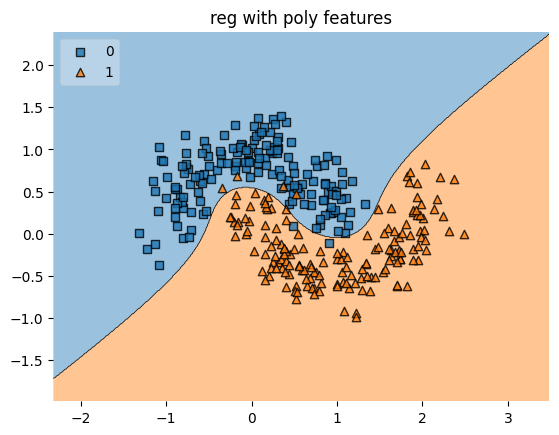

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

pipe = Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(include_bias=False)), ('reg', LogisticRegression())])

param_grid = {'poly__degree': range(1,5), 'poly__interaction_only' : [True, False]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print(grid.best_params_)

best_model = grid.best_estimator_
y_pred_reg = best_model.predict(X_test)
accuracy_reg = accuracy_score(y_test, y_pred_reg)
print(f"accuracy_reg = {accuracy_reg:.4f}")

plot_decisions(X_train, y_train, best_model, 'reg with poly features')

I use third degree polynomial for logistic regression. 

Accuracy in the regression is higher than in the svm_poly.

Boundary in the logistic regression more flexible than in svm_poly. 

## 1.4 Harder problem

Let's make this task a bit more challenging via upgrading dataset:

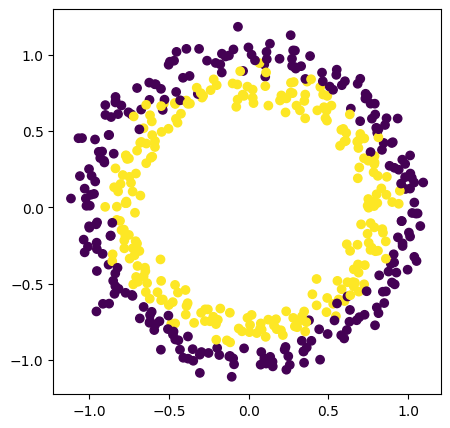

In [28]:
from sklearn.datasets import make_circles

circles_points, circles_labels = make_circles(n_samples=500, noise=0.06, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(circles_points[:, 0], circles_points[:, 1], c=circles_labels)

And even more:

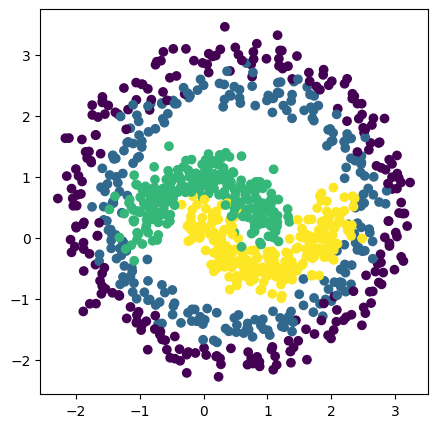

In [29]:
points = np.vstack((circles_points*2.5 + 0.5, moons_points))
labels = np.hstack((circles_labels, moons_labels + 2)) # + 2 to distinct moons classes

plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1], c=labels)

Now do your best using all the approaches above!

Tune LR with generated features, SVM with appropriate kernel of your choice. You may add some of your loved models to demonstrate their (and your) strength. Again plot decision regions, calculate metric.

Justify the results in a few phrases.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(points, labels, test_size=0.35)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=5, include_bias=False)),
                ('reg', LogisticRegression(max_iter=500))])
accuracy_lr = 0.9029


/home/dima/Документы/ml/.venv/lib/python3.12/site-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


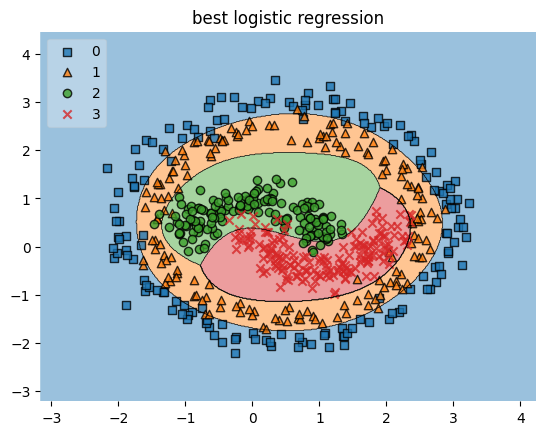

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=1000, gamma=0.1, random_state=42))])
accuracy_svm = 0.9200


/home/dima/Документы/ml/.venv/lib/python3.12/site-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


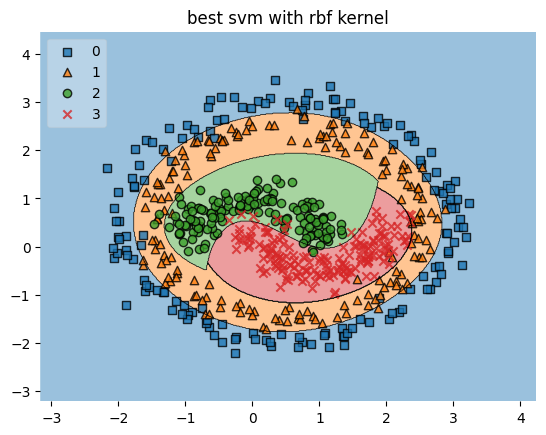

In [31]:
pipe = Pipeline([('scaler', StandardScaler()), 
                 ('poly', PolynomialFeatures(include_bias=False)), 
                 ('reg', LogisticRegression(max_iter=500))])
param_grid = {'poly__degree': range(1,6), 'poly__interaction_only' : [True, False]}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(grid.best_estimator_)
print(f"accuracy_lr = {accuracy:.4f}")

plot_decisions(X_train, y_train, grid, 'best logistic regression')

pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(tol=1e-3, random_state=42))])
param_grid = {'svm__C': [0.01, 0.1, 1, 10, 100, 1000, 10000], 'svm__gamma': [0.1, 0.01], 'svm__kernel': ['rbf']}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(grid.best_estimator_)
print(f"accuracy_svm = {accuracy:.4f}")

plot_decisions(X_train, y_train, grid, 'best svm with rbf kernel')